In [15]:
# Start by importing necessary packages
import requests
import pandas as pd
import numpy as np
from IPython.display import display
from io import StringIO

from dstapi import DstApi # The helper class

In [16]:
# Directly embed parameters in the URL with response.get()
requests.get('https://api.statbank.dk/v1' + '/tableinfo' + "?id=metrox1&format=JSON").json()

# Pass a dictionary of parameters to requests.get()
params = {'id': 'AFG6', 'format': 'JSON'}
requests.get('https://api.statbank.dk/v1' + '/tableinfo', params=params).json()

# Use response.post() - note the change in the name of the parameter about the table's name
# I'm also adding here a language parameter - most tables are available in both Danish and English
params = {'table': 'AFG6', 'format': 'JSON', 'lang':'da'}
requests.post('https://api.statbank.dk/v1' + '/tableinfo', json=params).json()

{'id': 'AFG6',
 'text': 'Afgrøder',
 'description': 'Afgrøder efter afgrøde, enhed, areal og tid',
 'unit': '-',
 'suppressedDataValue': '0',
 'updated': '2025-05-14T08:00:00',
 'active': True,
 'contacts': [{'name': 'Karsten Kjeld Larsen',
   'phone': '+4521295576',
   'mail': 'kkl@dst.dk'}],
 'documentation': {'id': '02717309-7893-4229-8a45-19384079c800',
  'url': 'https://www.dst.dk/statistikdokumentation/02717309-7893-4229-8a45-19384079c800'},
 'footnote': None,
 'variables': [{'id': 'AFGRØDE',
   'text': 'afgrøde',
   'elimination': True,
   'time': False,
   'values': [{'id': '000', 'text': 'Landbrug og gartneri i alt'},
    {'id': '005', 'text': '1. Korn til modenhed'},
    {'id': '010', 'text': '1.1 Hvede'},
    {'id': '015', 'text': '1.1.1 Vinterhvede'},
    {'id': '020', 'text': '1.1.2 Vårhvede'},
    {'id': '025', 'text': '1.2 Byg'},
    {'id': '030', 'text': '1.2.1 Vinterbyg'},
    {'id': '035', 'text': '1.2.2 Vårbyg'},
    {'id': '040', 'text': '1.3 Rug'},
    {'id': '045'

In [17]:
# Initialize the class with the target table
IO_landbrug = DstApi('AFG6')

# Get the table summary
IO_landbrug.tablesummary(language='da')

Table AFG6: Afgrøder efter afgrøde, enhed, areal og tid
Last update: 2025-05-14T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,AFGRØDE,61,000,Landbrug og gartneri i alt,300,C. Skov på landbrugbedrifter,False
1,ENHED,2,ANTAL,Bedrifter (antal),HA,Hektar,False
2,AREAL1,9,AIALT,I alt,A220,"200,0 ha og derover",False
3,Tid,43,1982,1982,2024,2024,True


In [18]:
levels = IO_landbrug.variable_levels('AFGRØDE', language='da')
print(levels.to_string(index=False))

 id                                                      text
000                                Landbrug og gartneri i alt
005                                      1. Korn til modenhed
010                                                 1.1 Hvede
015                                         1.1.1 Vinterhvede
020                                            1.1.2 Vårhvede
025                                                   1.2 Byg
030                                           1.2.1 Vinterbyg
035                                              1.2.2 Vårbyg
040                                                   1.3 Rug
045                                                 1.4 Havre
050                                             1.5 Triticale
055                                     1.6 Majs til modenhed
060                                1.7 Blandsæd og andet korn
065                                   2. Bælgsæd til modenhed
070                                    2.1 Ærter til modenhed
075     

In [19]:
params = {
    'table': 'AFG6',
    'format': 'BULK',
    'variables': [
        {'code': 'AFGRØDE', 'values': ['000','245','255']},
        {'code': 'ENHED', 'values': ['HA']},
        {'code': 'AREAL1', 'values': ['AIALT']},
        {'code': 'TID', 'values': ['*']}
    ]
}
r = requests.post('https://api.statbank.dk/v1' + '/data', json=params)
print(r.text[:200])


AFGRØDE;ENHED;AREAL1;TID;INDHOLD
Landbrug og gartneri i alt;Hektar;I alt;2014;2652026
8. Græs uden for omdrift;Hektar;I alt;2014;192617
10. Braklægning;Hektar;I alt;2014;21783
8. Græs uden for omd


In [20]:
df = pd.read_csv(
    StringIO(
        requests.post('https://api.statbank.dk/v1' + '/data', json=params).text
    ), sep=';'
)
print(df.columns.tolist())
print(df.head())

['AFGRØDE', 'ENHED', 'AREAL1', 'TID', 'INDHOLD']
                      AFGRØDE   ENHED AREAL1   TID  INDHOLD
0  Landbrug og gartneri i alt  Hektar  I alt  2014  2652026
1    8. Græs uden for omdrift  Hektar  I alt  2014   192617
2             10. Braklægning  Hektar  I alt  2014    21783
3    8. Græs uden for omdrift  Hektar  I alt  2002   177546
4             10. Braklægning  Hektar  I alt  2002   204721


# Behandler og summer over data

## Tilgang

In [21]:
# 1) Sørg for at INDHOLD er tal (DK-format: komma som decimal)
df["INDHOLD"] = (
    df["INDHOLD"].astype(str)
      .str.replace("\u00a0", "", regex=False)  # non-breaking space
      .str.replace(" ", "", regex=False)       # mellemrum som tusindtals-sep
      .str.replace(".", "", regex=False)       # punktum som tusindtals-sep (hvis findes)
      .str.replace(",", ".", regex=False)      # komma -> punktum (decimal)
)
df["INDHOLD"] = pd.to_numeric(df["INDHOLD"], errors="coerce")



In [22]:
#Trækker braklægning og græs fra
df_total = df[df['AFGRØDE'] == 'Landbrug og gartneri i alt'].copy().fillna(0)
df_gras = df[df['AFGRØDE'] == '8. Græs uden for omdrift'].copy().fillna(0)
df_brak = df[df['AFGRØDE'] == '10. Braklægning'].copy().fillna(0)

# Nu kan du droppe kolonner uden warning
df_total.drop(columns=['AFGRØDE'], inplace=True)
df_gras.drop(columns=['AFGRØDE'], inplace=True)
df_brak.drop(columns=['AFGRØDE'], inplace=True)

# Sæt index først for at sikre korrekt alignment
df_total = df_total.set_index(['ENHED', 'AREAL1', 'TID'])
df_gras = df_gras.set_index(['ENHED', 'AREAL1', 'TID'])
df_brak = df_brak.set_index(['ENHED', 'AREAL1', 'TID'])

# Subtraher Series (nu med samme index)
df_reduc = (df_total['INDHOLD'] - df_gras['INDHOLD'] - df_brak['INDHOLD'])/1000000

# Konverter til DataFrame og reset index
df_reduc = df_reduc.reset_index(name='INDHOLD')
df_reduc.drop(columns=['ENHED'],inplace=True)
df_reduc.drop(columns=['AREAL1'],inplace=True)
df_reduc

,TID,INDHOLD
0,1982,2.622497
1,1983,2.609892
2,1984,2.626380
3,1985,2.613536
4,1986,2.604464
5,1987,2.587243
6,1988,2.569828
7,1989,2.555043
8,1990,2.571041
9,1991,2.557627


# Gem udvalgt data

Det nye datasæt har 43 rækker.


,TID,INDHOLD
0,1982,2.622497
1,1983,2.609892
2,1984,2.626380
3,1985,2.613536
4,1986,2.604464


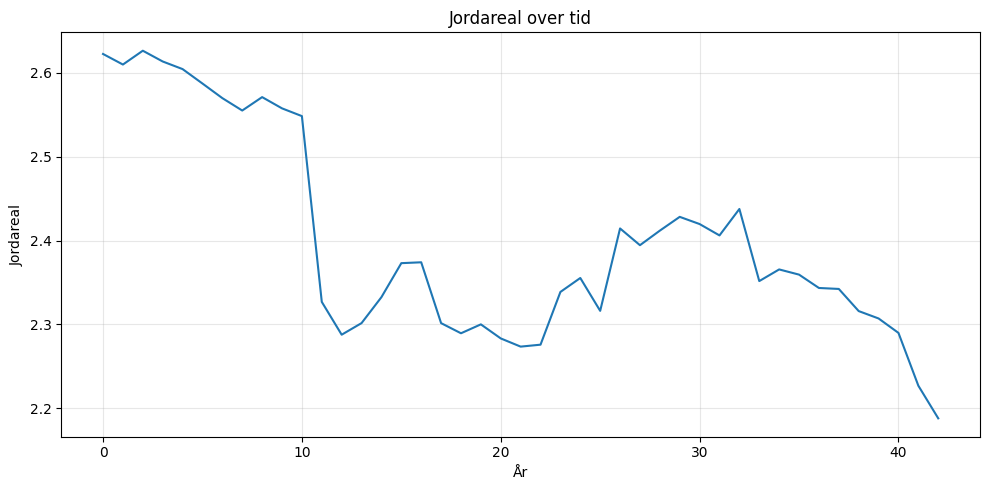

In [23]:
# 3. Tjek resultatet
print(f"Det nye datasæt har {df_reduc.shape[0]} rækker.")
display(df_reduc.head())
df_reduc.to_csv('Data69/landbrugsdata_jordareal.csv', index=False)
d =df_reduc
# Gør den "wide": år som index, branche som kolonner
# d_wide = d.unstack('ANVENDELSE').sort_index()
import matplotlib.pyplot as plt
# Plot
plt.figure(figsize=(10, 5))
plt.plot(d.index, d['INDHOLD'], label='Jordareal')
# plt.plot(p.index, p['Pt'], label='Jordpris')
plt.xlabel("År")
plt.ylabel("Jordareal")
plt.title("Jordareal over tid")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Jordpris

In [24]:
# 1. Indlæs filen. 
# 'skiprows' skal matche antallet af tomme/tekst-rækker før dine årstal (ser ud til ca. 4 i billedet)
df_jord = pd.read_excel('Data69/Jordpris.xlsx', skiprows=2)
df_jord = df_jord.dropna(how='all', axis=0)
# 2. Find rækken baseret på teksten i den første kolonne (B i dit ark)
# Vi antager at kolonnen med teksten nu er din index-kolonne eller første kolonne
row_name = 'Arable land, buying price (DKK per ha)'
mask = df_jord.stack().str.contains('Arable land, buying price \(DKK per ha\)', na=False).unstack().any(axis=1)
price_row = df_jord[mask]

price_row
# 3. Formater til en pæn DataFrame (transpose den, så år er rækker)
# Vi fjerner den første kolonne (teksten) og vender tabellen om
final_df = price_row.iloc[:, 2:].transpose()

# Giv kolonnerne navne
final_df.columns = ['INDHOLD']
final_df.index.name = 'TID'
final_df.reset_index(inplace=True)

print(final_df)
final_df.to_csv('Data69/jordpris.csv', index=False)

     TID        INDHOLD
0   1982   45825.502031
1   1983   51810.607599
2   1984   57156.987288
3   1985   67819.589181
4   1986   66007.478465
5   1987   65298.183644
6   1988   65307.752545
7   1989   66502.462164
8   1990   61563.378889
9   1991   64213.928118
10  1992   62699.549849
11  1993   61858.598515
12  1994   63305.492682
13  1995   71828.408842
14  1996   73542.951833
15  1997   83973.522566
16  1998   91592.738403
17  1999   99478.808105
18  2000  105976.187244
19  2001   117087.74106
20  2002  118049.705115
21  2003   119573.41673
22  2004  132817.645523
23  2005       148000.0
24  2006       185000.0
25  2007       219990.0
26  2008       257325.0
27  2009       210010.0
28  2010       171596.0
29  2011       130209.0
30  2012       130729.0
31  2013       117152.0
32  2014       128287.0
33  2015       139866.0
34  2016       130916.0
35  2017       128897.0
36  2018       132099.0
37  2019       131251.0
38  2020       130383.0
39  2021       135451.0
40  2022       1

<>:8: SyntaxWarning: invalid escape sequence '\('
<>:8: SyntaxWarning: invalid escape sequence '\('
C:\Users\b431385\AppData\Local\Temp\ipykernel_11920\3670992004.py:8: SyntaxWarning: invalid escape sequence '\('
  mask = df_jord.stack().str.contains('Arable land, buying price \(DKK per ha\)', na=False).unstack().any(axis=1)


In [25]:
df_jord = pd.read_excel('Data69/Grundskyld Landbruget.xlsx', header=0)
df_jord = df_jord.dropna(how='all', axis=0).dropna(how='all', axis=1)

mask = df_jord.iloc[:, 0] == 10000
price_row = df_jord[mask]

final_df = price_row.iloc[:, 1:].T.reset_index()
final_df.columns = ['TID', 'INDHOLD']

final_df['INDHOLD'] = final_df['INDHOLD'] / 1000

print(final_df)
final_df.to_csv('Data69/grundskyld.csv', index=False)

     TID      INDHOLD
0   1966    87.170267
1   1967   100.725916
2   1968   104.862600
3   1969   107.941691
4   1970   140.599710
5   1971   161.073295
6   1972   157.263859
7   1973   152.452505
8   1974   175.818612
9   1975   197.094357
10  1976   201.623355
11  1977   195.686735
12  1978   229.031049
13  1979   250.673333
14  1980   280.156487
15  1981   278.492619
16  1982   281.365570
17  1983   262.841891
18  1984   254.300362
19  1985   270.654344
20  1986   306.215634
21  1987   399.887573
22  1988   403.048278
23  1989   406.908744
24  1990   401.708749
25  1991   399.461541
26  1992   418.271987
27  1993   488.461223
28  1994   471.841392
29  1995   743.768397
30  1996   577.731701
31  1997   666.692058
32  1998   677.690684
33  1999   816.619176
34  2000   691.264888
35  2001   946.666287
36  2002  1004.459238
37  2003  1066.796375
38  2004  1013.607944
39  2005   892.020600
40  2006   891.767747
41  2007   911.139037
42  2008   974.045572
43  2009  1374.294280
44  2010  